In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PHASE 1: STOCHASTIC SIMULATION (THE LOOP)

# 1. Define our Market Parameters
np.random.seed(42)          # Fixes the random numbers so your results match mine
S0 = 100                    # Initial stock price ($100)
mu = 0.05                   # Expected annual return (5% drift)
sigma = 0.20                # Annual volatility (20%)
T = 1.0                     # Time horizon (1 year)
M = 252                     # Number of trading steps (252 days in a year)
N = 1000                    # Number of simulated paths (scenarios)

# 2. Calculate time increments
dt = T / M                  # Change in time per step (1 / 252)

# 3. Generate the Random Shocks Matrix
random_shocks = np.random.normal(0, 1, size=(M, N))

# 4. Initialize our Price Matrix with zeros
price_paths = np.zeros((M + 1, N))
price_paths[0] = S0         # Set Day 0 to our starting price ($100)

# 5. Run the Simulation Loop across time
for t in range(1, M + 1):
    # Retrieve the row of 1,000 random shocks for this specific day
    shock = random_shocks[t - 1]
    
    # Mathematical formulas for the components
    drift_component = (mu - 0.5 * sigma**2) * dt
    shock_component = sigma * np.sqrt(dt) * shock
    
    # Vectorized compounding to update all 1,000 paths at once
    price_paths[t] = price_paths[t - 1] * np.exp(drift_component + shock_component)

In [29]:
# PHASE 2: VALUE-AT-RISK (RISK ENGINE)

# Day 252 Ending Prices
ending_prices = price_paths[-1]

# Final Return %
final_returns = (ending_prices - S0) / S0

# The Bottom 5% 
var_5pct_return = np.percentile(final_returns, 5)

# Dollars Lost At 5%
dollar_var_95 = -var_5pct_return * S0

# Selects 0-5%
tail_losses = final_returns[final_returns <= var_5pct_return]

# Finds Average Loss %
expected_shortfall_return = tail_losses.mean()

# Average Dollars Lost Below 5%
dollar_es_95 = -expected_shortfall_return * S0

--- PORTFOLIO RISK METRICS ---
Average Ending Stock Price: $105.20
Worst Simulated Outcome:    $55.67
Best Simulated Outcome:     $183.51
95% Value-at-Risk (VaR):    $25.74
Average Loss below 5% (ES): $31.92
------------------------------



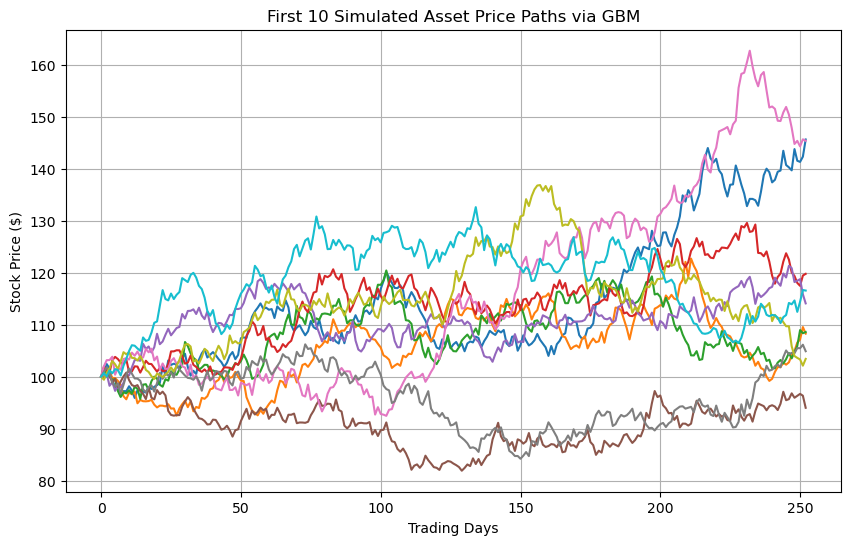

In [33]:
# PHASE 3: PRINT THE RISK RESULTS

print("--- PORTFOLIO RISK METRICS ---")
print(f"Average Ending Stock Price: ${ending_prices.mean():.2f}")
print(f"Worst Simulated Outcome:    ${ending_prices.min():.2f}")
print(f"Best Simulated Outcome:     ${ending_prices.max():.2f}")
print(f"95% Value-at-Risk (VaR):    ${dollar_var_95:.2f}")
print(f"Average Loss below 5% (ES): ${dollar_es_95:.2f}")
print("------------------------------\n")


plt.figure(figsize=(10, 6))
plt.plot(price_paths[:, :10]) # Plotting first 10 columns
plt.title("First 10 Simulated Asset Price Paths via GBM")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.grid(True)
plt.show()